In [1]:
import os; WORKDIR = f"{os.getcwd()}/.."
import sys; sys.path.append(f"{WORKDIR}/libPython")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.utils import shuffle
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

#import torch
#import torch.nn.functional as F
#from torch.utils.data import DataLoader
#from DataManager import ArrayDataset

In [2]:
# input features
features = ["j1_energy", "j1_px", "j1_py", "j1_pz", "j1_chEmEF", "j1_chHEF", "j1_neEmEF", "j1_neHEF", "j1_muEF", "j1_btagDeepFlavB", "j1_btagDeepFlavQG",
            "j2_energy", "j2_px", "j2_py", "j2_pz", "j2_chEmEF", "j2_chHEF", "j2_neEmEF", "j2_neHEF", "j2_muEF", "j2_btagDeepFlavB", "j2_btagDeepFlavQG",
            "j3_energy", "j3_px", "j3_py", "j3_pz", "j3_chEmEF", "j3_chHEF", "j3_neEmEF", "j3_neHEF", "j3_muEF", "j3_btagDeepFlavB", "j3_btagDeepFlavQG",
            "j4_energy", "j4_px", "j4_py", "j4_pz", "j4_chEmEF", "j4_chHEF", "j4_neEmEF", "j4_neHEF", "j4_muEF", "j4_btagDeepFlavB", "j4_btagDeepFlavQG",
            "avg_deltaR", "Nj", "HT"]

In [3]:
# load dataset
sigCSV = pd.read_csv(f"{WORKDIR}/DATA/TT/sample.csv", index_col=0); sigCSV["label"] = 1
bkgCSV = pd.read_csv(f"{WORKDIR}/DATA/QCD/sample.csv", index_col=0); bkgCSV["label"] = 0

sample = shuffle(pd.concat([sigCSV, bkgCSV], ignore_index=True), random_state=42)
trainset = sample[:int(len(sample)*0.6)]
validset = sample[int(len(sample)*0.6):int(len(sample)*0.7)]
testset = sample[int(len(sample)*0.7):]

#trainLoader = DataLoader(ArrayDataset(trainset), batch_size=1024, pin_memory=True, shuffle=True)
#validLoader = DataLoader(ArrayDataset(validset), batch_size=1024, pin_memory=True, shuffle=False)
#testLoader  = DataLoader(ArrayDataset(testset), batch_size=1024, pin_memory=True, shuffle=False)

In [4]:
# train a random forest classifier
X_train, y_train = trainset.to_numpy()[:, :-1], trainset.to_numpy()[:, -1]
X_valid, y_valid = validset.to_numpy()[:, :-1], validset.to_numpy()[:, -1]
X_test, y_test = testset.to_numpy()[:, :-1], testset.to_numpy()[:, -1]
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [5]:
# results
y_pred = clf.predict(X_train)
correct = (y_pred == y_train).sum()
print(f"[train acc] {correct / len(y_pred)}")

y_pred = clf.predict(X_valid)
correct = (y_pred == y_valid).sum()
print(f"[valid acc] {correct / len(y_valid)}")

[train acc] 1.0
[valid acc] 0.89175


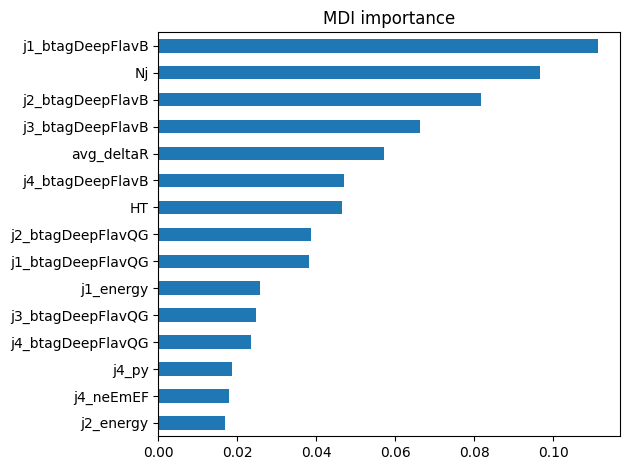

In [6]:
mdi_importances = pd.Series(clf.feature_importances_, index=features)
tree_importance_sorted_idex = np.argsort(clf.feature_importances_)
tree_indices = np.arange(0, len(clf.feature_importances_))+0.5

outPath = f"{WORKDIR}/outputs/ex1/plots/ex1-feature_importance.png"
os.makedirs(os.path.dirname(outPath), exist_ok=True) 

plt.figure()
mdi_importances.sort_values().iloc[-15:].plot.barh()
plt.title("MDI importance")
plt.tight_layout()
plt.savefig(outPath)

In [7]:
train_result = permutation_importance(clf, X_train, y_train, n_repeats=10, random_state=42, n_jobs=10)
valid_result = permutation_importance(clf, X_valid, y_valid, n_repeats=10, random_state=42, n_jobs=10)

sorted_importances_idx = train_result.importances_mean.argsort()

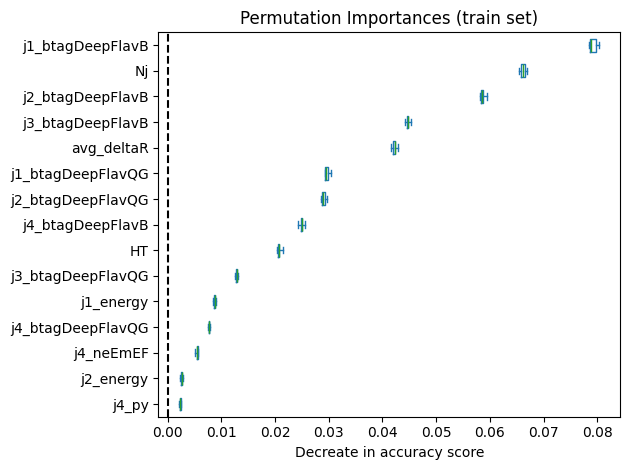

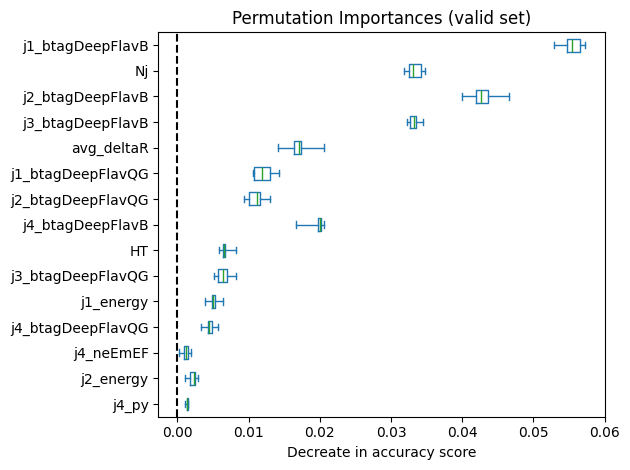

In [8]:
train_importances = pd.DataFrame(
    train_result.importances[sorted_importances_idx].T,
    columns=[features[idx] for idx in sorted_importances_idx]
)
valid_importances = pd.DataFrame(
    valid_result.importances[sorted_importances_idx].T,
    columns=[features[idx] for idx in sorted_importances_idx]
)

for name, importances in zip(["train", "valid"], [train_importances, valid_importances]):
    ax = importances[importances.columns[-15:]].plot.box(vert=False, whis=10)
    ax.set_title(f"Permutation Importances ({name} set)")
    ax.set_xlabel("Decreate in accuracy score")
    ax.axvline(x=0, color="k", linestyle="--")
    ax.figure.tight_layout()

[train acc] 0.8751416666666667
[valid acc] 0.87295


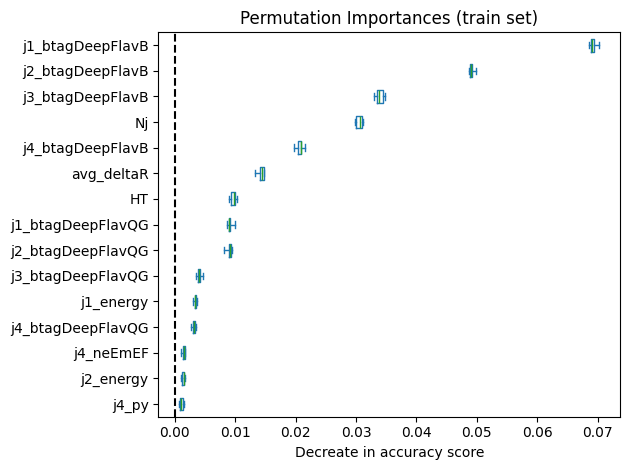

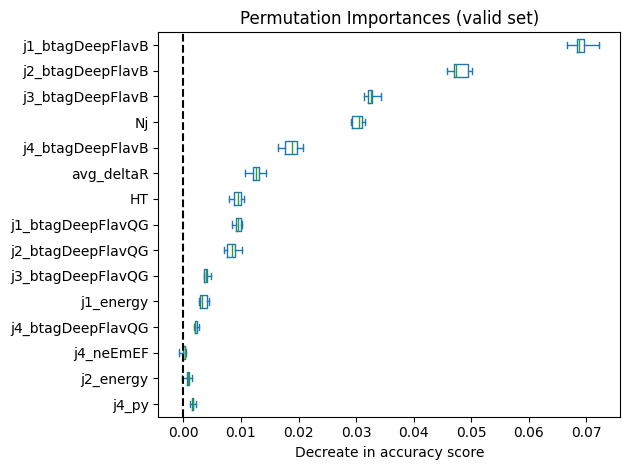

In [10]:
# to reduce the overfitting problem,
# you can control max_depth / min_sample_leaf variables
# https://www.es.utoronto.ca/wp-content/uploads/2019/03/Lecture_09.pdf
clf = RandomForestClassifier(max_depth=7, random_state=42)
clf.fit(X_train, y_train)

# results
y_pred = clf.predict(X_train)
correct = (y_pred == y_train).sum()
print(f"[train acc] {correct / len(y_pred)}")

y_pred = clf.predict(X_valid)
correct = (y_pred == y_valid).sum()
print(f"[valid acc] {correct / len(y_valid)}")

# feature importances
train_result = permutation_importance(clf, X_train, y_train, n_repeats=10, random_state=42, n_jobs=10)
valid_result = permutation_importance(clf, X_valid, y_valid, n_repeats=10, random_state=42, n_jobs=10)

sorted_importances_idx = train_result.importances_mean.argsort()

train_importances = pd.DataFrame(
    train_result.importances[sorted_importances_idx].T,
    columns=[features[idx] for idx in sorted_importances_idx]
)
valid_importances = pd.DataFrame(
    valid_result.importances[sorted_importances_idx].T,
    columns=[features[idx] for idx in sorted_importances_idx]
)

for name, importances in zip(["train", "valid"], [train_importances, valid_importances]):
    ax = importances[importances.columns[-15:]].plot.box(vert=False, whis=10)
    ax.set_title(f"Permutation Importances ({name} set)")
    ax.set_xlabel("Decreate in accuracy score")
    ax.axvline(x=0, color="k", linestyle="--")
    ax.figure.tight_layout()

[train acc] 0.8563916666666667
[valid acc] 0.85715


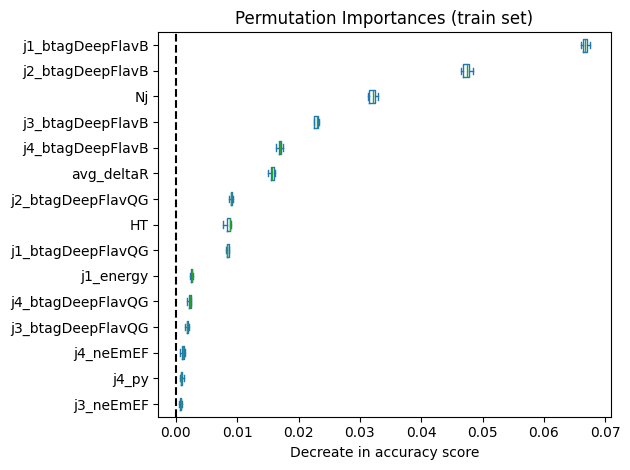

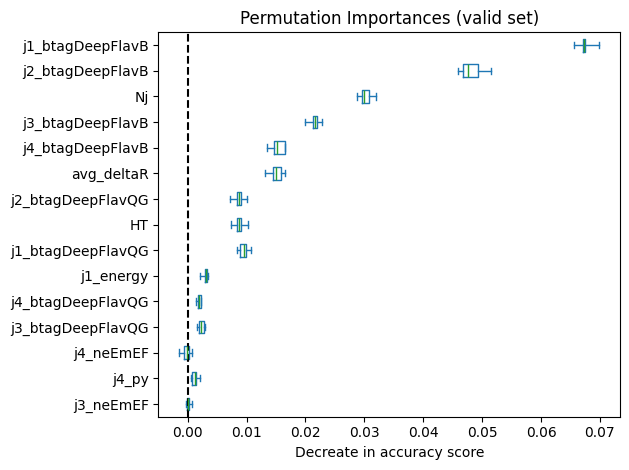

In [11]:
clf = RandomForestClassifier(max_depth=4, random_state=42)
clf.fit(X_train, y_train)

# results
y_pred = clf.predict(X_train)
correct = (y_pred == y_train).sum()
print(f"[train acc] {correct / len(y_pred)}")

y_pred = clf.predict(X_valid)
correct = (y_pred == y_valid).sum()
print(f"[valid acc] {correct / len(y_valid)}")

# feature importances
train_result = permutation_importance(clf, X_train, y_train, n_repeats=10, random_state=42, n_jobs=10)
valid_result = permutation_importance(clf, X_valid, y_valid, n_repeats=10, random_state=42, n_jobs=10)

sorted_importances_idx = train_result.importances_mean.argsort()

train_importances = pd.DataFrame(
    train_result.importances[sorted_importances_idx].T,
    columns=[features[idx] for idx in sorted_importances_idx]
)
valid_importances = pd.DataFrame(
    valid_result.importances[sorted_importances_idx].T,
    columns=[features[idx] for idx in sorted_importances_idx]
)

for name, importances in zip(["train", "valid"], [train_importances, valid_importances]):
    ax = importances[importances.columns[-15:]].plot.box(vert=False, whis=10)
    ax.set_title(f"Permutation Importances ({name} set)")
    ax.set_xlabel("Decreate in accuracy score")
    ax.axvline(x=0, color="k", linestyle="--")
    ax.figure.tight_layout()